# Distance-3 Toric Code with Qiskit Syndrome Extraction and MWPM

In [25]:
# %pip install qiskit qiskit-aer pymatching matplotlib

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from pymatching import Matching # For MWPM decoding


## 1. Geometry of the distance-3 toric code

We use the standard toric-code construction on an $L\times L$ square lattice with **periodic boundary conditions**.

Qubits live on **edges**:
- one horizontal edge per lattice cell
- one vertical edge per lattice cell

So the total number of physical qubits is $n = 2L^2$.

For $L=3$, this gives:
- $n = 18$ physical qubits
- $L^2 = 9$ star checks
- $L^2 = 9$ plaquette checks
- $k = 2$ logical qubits

We index edges by two helper functions:
- `h(x, y)` for horizontal edges
- `v(x, y)` for vertical edges


In [26]:
@dataclass
class ToricCode:
    L: int

    def __post_init__(self):
        self.n = 2 * self.L * self.L
        self.n_star = self.L * self.L
        self.n_plaquette = self.L * self.L

    def mod(self, x: int) -> int:
        return x % self.L

    def h(self, x: int, y: int) -> int:
        x, y = self.mod(x), self.mod(y)
        return y * self.L + x

    def v(self, x: int, y: int) -> int:
        x, y = self.mod(x), self.mod(y)
        return self.L * self.L + y * self.L + x

    def star_index(self, x: int, y: int) -> int:
        x, y = self.mod(x), self.mod(y)
        return y * self.L + x

    def plaquette_index(self, x: int, y: int) -> int:
        x, y = self.mod(x), self.mod(y)
        return y * self.L + x

    def star_edges(self, x: int, y: int) -> List[int]:
        return [
            self.h(x, y),
            self.h(x - 1, y),
            self.v(x, y),
            self.v(x, y - 1),
        ]

    def plaquette_edges(self, x: int, y: int) -> List[int]:
        return [
            self.h(x, y),
            self.v(x + 1, y),
            self.h(x, y + 1),
            self.v(x, y),
        ]

code = ToricCode(2)
print("distance d =", code.L)
print("physical qubits n =", code.n)
print("star checks =", code.n_star)
print("plaquette checks =", code.n_plaquette)


distance d = 2
physical qubits n = 8
star checks = 4
plaquette checks = 4


## 2. Stabilizers and parity-check matrices

The toric code is a CSS stabilizer code with two stabilizer families:

### Star stabilizers
Each star operator acts with $X$ on the four edges touching a vertex.
These detect **Z-type errors**.

### Plaquette stabilizers
Each plaquette operator acts with $Z$ on the four edges around a square face.
These detect **X-type errors**.

We encode them as binary parity-check matrices:
- `Hx`: star-check matrix
- `Hz`: plaquette-check matrix


In [27]:
def build_toric_pcm(L: int):
    code = ToricCode(L)

    Hx = np.zeros((code.n_star, code.n), dtype=np.uint8)
    Hz = np.zeros((code.n_plaquette, code.n), dtype=np.uint8)

    for x in range(L):
        for y in range(L):
            s = code.star_index(x, y)
            for q in code.star_edges(x, y):
                Hx[s, q] ^= 1 #+1 mod 2

            p = code.plaquette_index(x, y)
            for q in code.plaquette_edges(x, y):
                Hz[p, q] ^= 1

    return code, Hx, Hz

code, Hx, Hz = build_toric_pcm(2)
print("Hx shape =", Hx.shape)
print("Hz shape =", Hz.shape)


Hx shape = (4, 8)
Hz shape = (4, 8)


There is one global redundancy in each stabilizer family on a torus:
- the product of all star stabilizers is identity
- the product of all plaquette stabilizers is identity

So each matrix has rank \(L^2 - 1\) when \(L=3\).


In [28]:
def binary_rank(M: np.ndarray) -> int:
    A = M.copy().astype(np.uint8)
    m, n = A.shape
    r = 0
    for c in range(n):
        pivot = None
        for i in range(r, m):
            if A[i, c]:
                pivot = i
                break
        if pivot is None:
            continue
        if pivot != r:
            A[[r, pivot]] = A[[pivot, r]]
        for i in range(m):
            if i != r and A[i, c]:
                A[i] ^= A[r]
        r += 1
        if r == m:
            break
    return r

print("rank(Hx) =", binary_rank(Hx))
print("rank(Hz) =", binary_rank(Hz))
print("encoded qubits k =", code.n - binary_rank(Hx) - binary_rank(Hz))


rank(Hx) = 3
rank(Hz) = 3
encoded qubits k = 2


## 3. Logical states

This section takes a Boolean $x\in \mathbb{F}_2^2$ and prepares the corresponding logical state in the Toric code $|x\rangle_L$.

### Logical operators
The Toric code on a torus encodes **two logical qubits**. They are represented by **non-contractible loops**:
- one loop winding around the x-direction
- one loop winding around the y-direction

For decoding:
- X-type residual errors are tested against Z-type logical loops
- Z-type residual errors are tested against X-type logical loops

A logical failure occurs if the residual error after decoding is **homologically nontrivial**.

### Build a logical state

We prepare a code-space state by constructing a statevector and using:

```python
qc.initialize(statevector, data_qubits)
```

The $|00\rangle_L$ logical state can be represented as a equal superposition over the **row space of the star-check matrix** acting on $|0\dots 0\rangle$

$$|00\rangle_L = \prod_s \frac{1+A_s}{2}|0\dots 0\rangle .$$

The remaining 3 logical states can be obtained by acting logical $X$ loops to the $|00\rangle_L$ logical state

$$|x_1,x_2\rangle_L = \overline{X}_1^{x_1}\overline{X}_2^{x_2}|00\rangle_L.$$

In [29]:
def build_logicals(code: ToricCode):
    n = code.n
    L = code.L

    X1 = np.zeros(n, dtype=np.uint8)
    X2 = np.zeros(n, dtype=np.uint8)
    Z1 = np.zeros(n, dtype=np.uint8)
    Z2 = np.zeros(n, dtype=np.uint8)

    for x in range(L):
        X1[code.h(x, 0)] = 1
        Z2[code.h(x, 0)] = 1

    for y in range(L):
        X2[code.v(0, y)] = 1
        Z1[code.v(0, y)] = 1

    LX = np.stack([X1, X2], axis=0)
    LZ = np.stack([Z1, Z2], axis=0)
    return LX, LZ

LX, LZ = build_logicals(code)


# find independent A_v operators
def gf2_row_basis(M: np.ndarray) -> np.ndarray:
    A = M.copy().astype(np.uint8)
    m, n = A.shape
    r = 0
    for c in range(n):
        pivot = None
        for i in range(r, m):
            if A[i, c]:
                pivot = i
                break
        if pivot is None:
            continue
        if pivot != r:
            A[[r, pivot]] = A[[pivot, r]]
        for i in range(m):
            if i != r and A[i, c]:
                A[i] ^= A[r]
        r += 1
        if r == m:
            break
    return A[:r].copy()

def bits_to_int(bits: np.ndarray) -> int:
    out = 0
    for i, b in enumerate(bits):
        out |= (int(b) << i)
    return out

def int_to_bits(idx: int, n: int) -> np.ndarray:
    return np.array([(idx >> i) & 1 for i in range(n)], dtype=np.uint8)

def build_logical_zero_zero_statevector(Hx: np.ndarray) -> np.ndarray:
    basis = gf2_row_basis(Hx)
    r, n = basis.shape

    support = set()
    zero = np.zeros(n, dtype=np.uint8)

    for mask in range(1 << r):
        v = zero.copy()
        for i in range(r):
            if (mask >> i) & 1:
                v ^= basis[i]
        support.add(bits_to_int(v))

    dim = 1 << n
    psi = np.zeros(dim, dtype=complex)
    amp = 1 / np.sqrt(len(support))
    for idx in support:
        psi[idx] = amp
    return psi

# Apply an X-string specified by x_vec to a computational-basis statevector.
def apply_binary_x_operator_to_statevector(psi: np.ndarray, x_vec: np.ndarray) -> np.ndarray:
    out = np.zeros_like(psi)

    mask = bits_to_int(x_vec)
    for idx, amp in enumerate(psi):
        out[idx ^ mask] = amp
    return out

def build_logical_statevector(Hx: np.ndarray, LX: np.ndarray, x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.uint8)
    if x.shape != (2,):
        raise ValueError("x must be a length-2 binary vector in F_2^2.")
    if np.any((x != 0) & (x != 1)):
        raise ValueError("Entries of x must be 0 or 1.")

    psi = build_logical_zero_zero_statevector(Hx)

    if x[0]:
        psi = apply_binary_x_operator_to_statevector(psi, LX[0])
    if x[1]:
        psi = apply_binary_x_operator_to_statevector(psi, LX[1])

    return psi

# Choose the logical basis state here:
x_logical = np.array([0, 0], dtype=np.uint8)

psi00 = build_logical_statevector(Hx, LX, x_logical)

print("Chosen logical label x =", x_logical)
print("Hilbert-space dimension =", len(psi00))
print("Number of nonzero amplitudes =", np.count_nonzero(np.abs(psi00) > 1e-12))
print("Norm =", np.linalg.norm(psi00))
print()



Chosen logical label x = [0 0]
Hilbert-space dimension = 256
Number of nonzero amplitudes = 8
Norm = 0.9999999999999999



## 4. The MWPM decoder

The toric code under Pauli noise separates naturally into two decoding sectors:

- **X-error sector**  
  detected by plaquette syndromes and decoded against `Hz`

- **Z-error sector**  
  detected by star syndromes and decoded against `Hx`

We use `pymatching`, which constructs an MWPM decoder directly from the parity-check matrix.


In [30]:
matching_X = Matching(Hz)
matching_Z = Matching(Hx)
print("MWPM decoders ready.")


MWPM decoders ready.


## 5. Qiskit stabilizer-measurement circuits

Now we build a quantum circuit that measures the stabilizers.

### Measuring a plaquette stabilizer $Z^{\otimes 4}$
- ancilla starts in $|0\rangle$
- apply CNOTs from data qubits to ancilla
- measure ancilla in the Z basis

### Measuring a star stabilizer $X^{\otimes 4}$
- ancilla starts in $|0\rangle$
- apply Hadamard gate to ancilla
- use ancilla as the control of CNOTs into the four data qubits
- apply Hadamard gate to ancilla again
- measure ancilla in the Z basis

This is equivalent to measuring the ancilla in the X basis.


In [31]:
def append_plaquette_measurements(qc: QuantumCircuit, code: ToricCode, data_reg, plaq_reg, c_plaq):
    for x in range(code.L):
        for y in range(code.L):
            p = code.plaquette_index(x, y)
            for q in code.plaquette_edges(x, y):
                qc.cx(data_reg[q], plaq_reg[p])
            qc.measure(plaq_reg[p], c_plaq[p])

def append_star_measurements(qc: QuantumCircuit, code: ToricCode, data_reg, star_reg, c_star):
    for x in range(code.L):
        for y in range(code.L):
            s = code.star_index(x, y)
            qc.h(star_reg[s])
            for q in code.star_edges(x, y):
                qc.cx(star_reg[s], data_reg[q])
            qc.h(star_reg[s])
            qc.measure(star_reg[s], c_star[s])


## 6. Sampling Pauli noise

We sample iid single-qubit Pauli noise:
- \(I\) with probability \(1-p\)
- \(X, Y, Z\) each with probability \(p/3\)

We store the error in symplectic binary form:
- `x_err[q] = 1` if the Pauli contains an X component
- `z_err[q] = 1` if the Pauli contains a Z component


In [32]:
def sample_pauli_error(n: int, p: float, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x_err = np.zeros(n, dtype=np.uint8)
    z_err = np.zeros(n, dtype=np.uint8)

    for q in range(n):
        if rng.random() >= p:
            continue
        pauli = rng.integers(1, 4)  # 1=X, 2=Y, 3=Z
        if pauli == 1:
            x_err[q] = 1
        elif pauli == 2:
            x_err[q] = 1
            z_err[q] = 1
        else:
            z_err[q] = 1

    return x_err, z_err

rng = np.random.default_rng(1234)
x_err, z_err = sample_pauli_error(code.n, p=0.2, rng=rng)
print("X weight =", int(x_err.sum()))
print("Z weight =", int(z_err.sum()))


X weight = 0
Z weight = 1


## 7. Build the full syndrome-extraction circuit

This circuit does four things:

1. initializes the data register in \(|0,0\rangle_L\)
2. applies a sampled Pauli error pattern with Qiskit gates
3. measures all plaquette syndromes
4. measures all star syndromes

This is the key bridge between the **quantum part** and the **classical decoder**.


16 total qubits in the circuit
8 classical bits


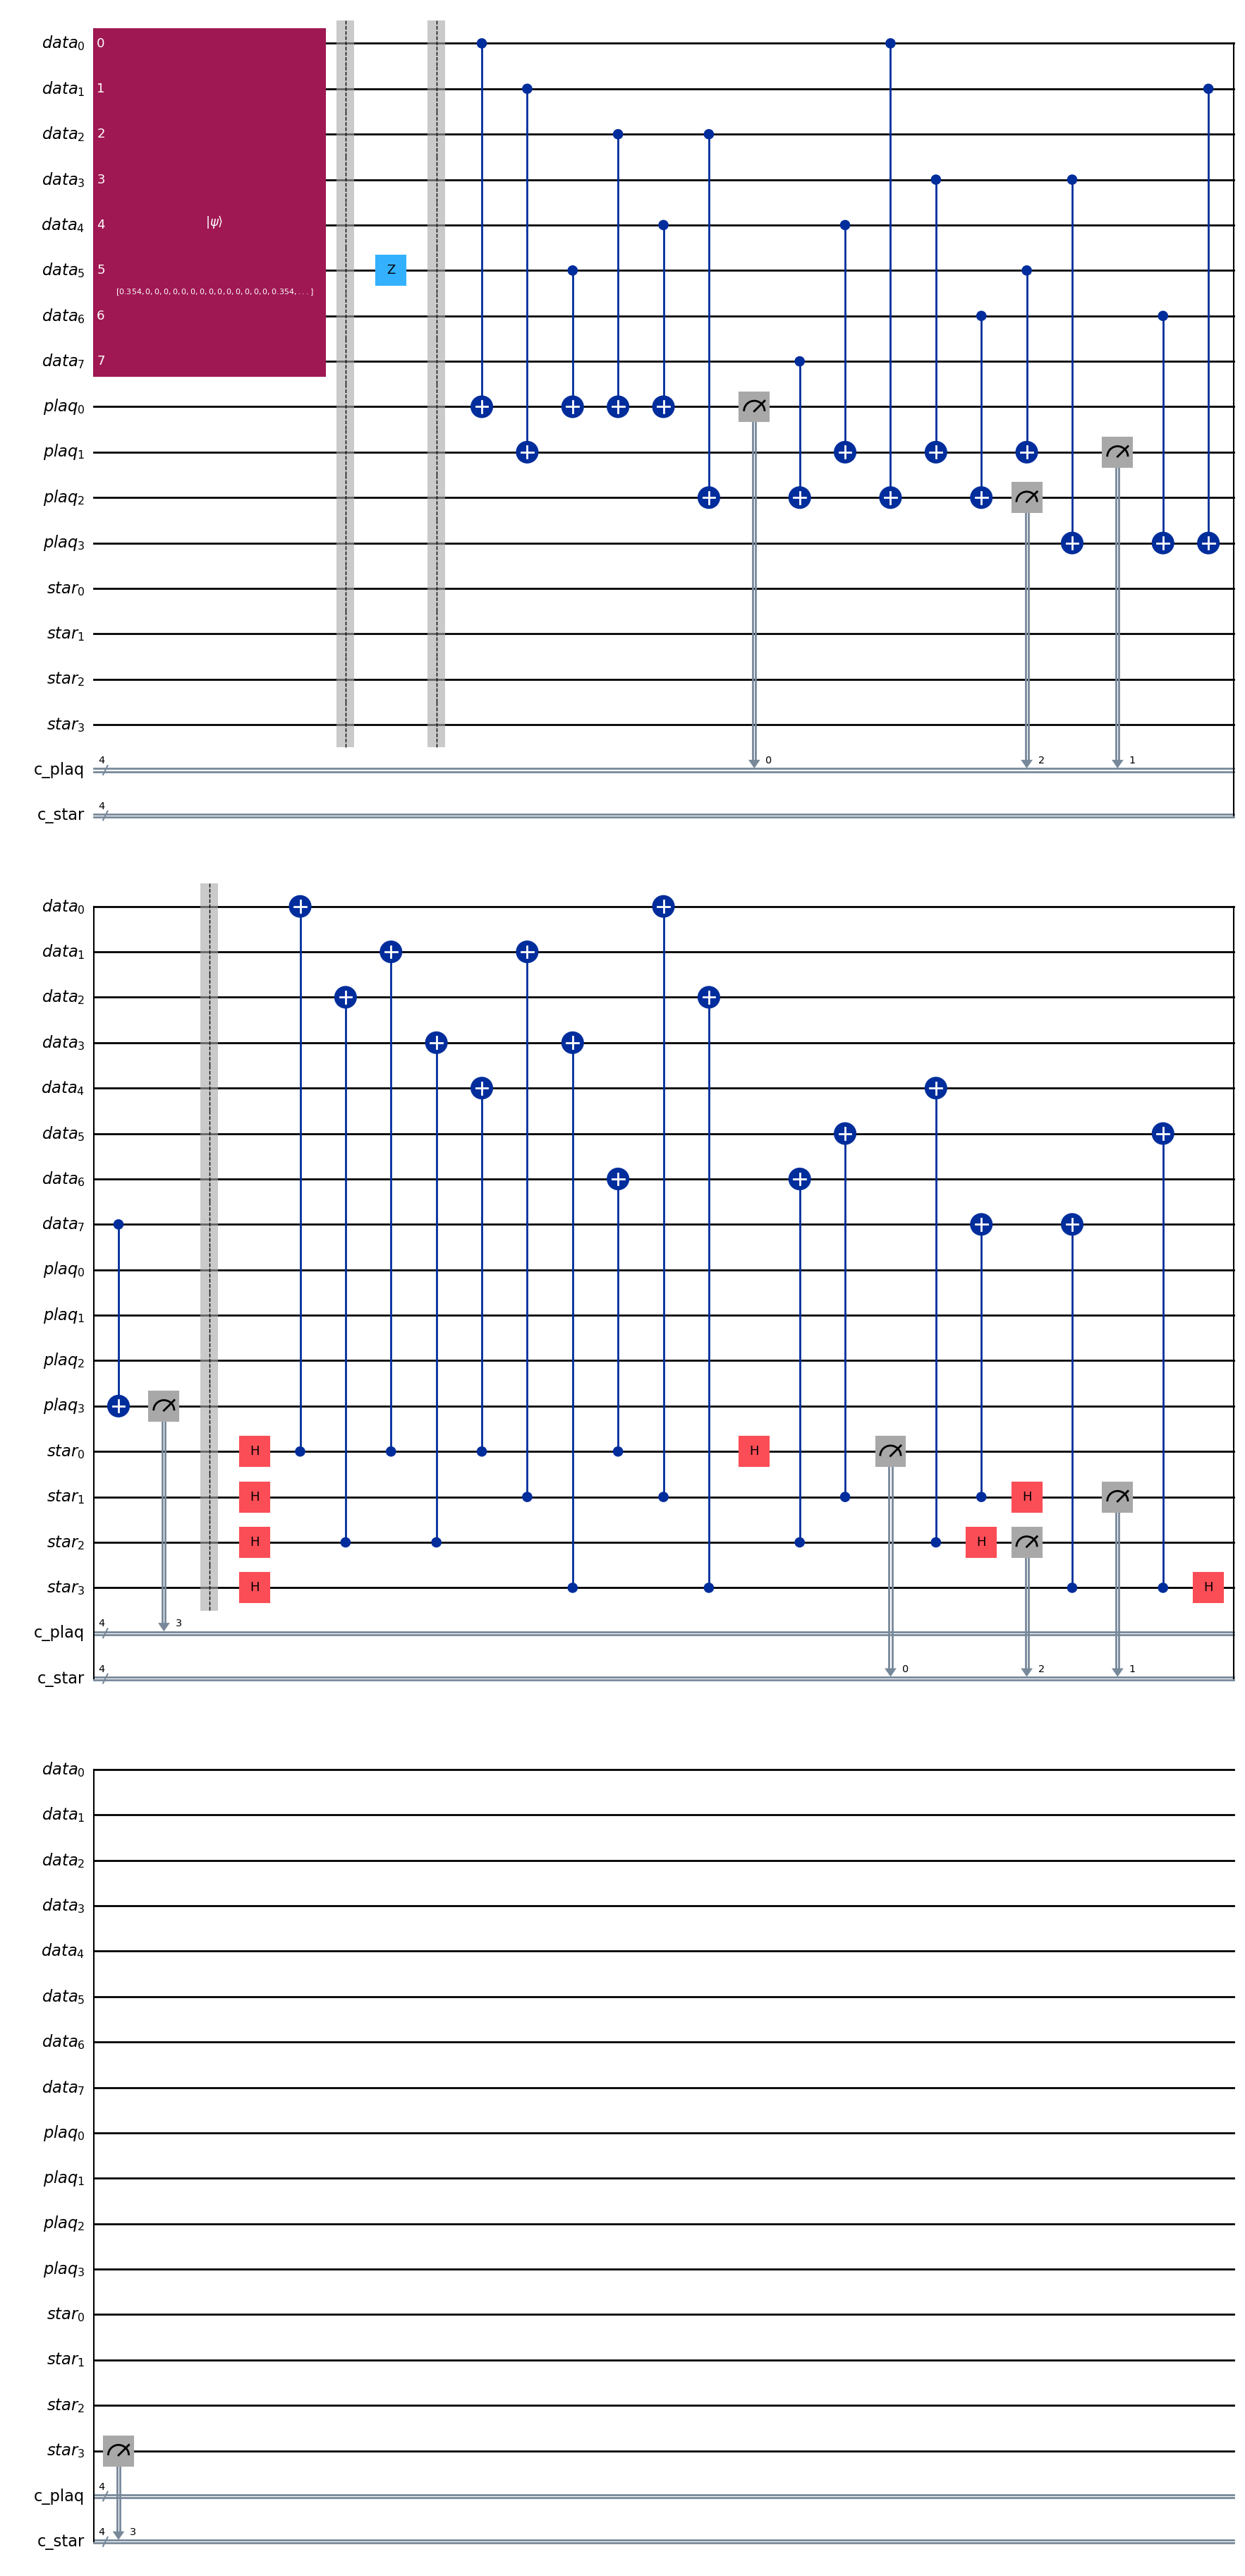

In [33]:
def apply_pauli_error_gates(qc: QuantumCircuit, data_reg, x_err: np.ndarray, z_err: np.ndarray):
    for q in range(len(x_err)):
        if x_err[q] and z_err[q]:
            qc.y(data_reg[q])
        elif x_err[q]:
            qc.x(data_reg[q])
        elif z_err[q]:
            qc.z(data_reg[q])

def build_syndrome_circuit(code: ToricCode, psi00: np.ndarray, x_err: np.ndarray, z_err: np.ndarray) -> QuantumCircuit:
    data = QuantumRegister(code.n, "data")
    plaq = QuantumRegister(code.n_plaquette, "plaq")
    star = QuantumRegister(code.n_star, "star")
    c_plaq = ClassicalRegister(code.n_plaquette, "c_plaq")
    c_star = ClassicalRegister(code.n_star, "c_star")

    qc = QuantumCircuit(data, plaq, star, c_plaq, c_star)
    qc.initialize(psi00, data)
    qc.barrier()

    apply_pauli_error_gates(qc, data, x_err, z_err)
    qc.barrier()

    append_plaquette_measurements(qc, code, data, plaq, c_plaq)
    qc.barrier()
    append_star_measurements(qc, code, data, star, c_star)

    return qc

x_logical = np.array([0, 0], dtype=np.uint8)
psi = build_logical_statevector(Hx, LX, x_logical)
#x_err, z_err = sample_pauli_error(code.n, p=0.3, rng=rng)

qc = build_syndrome_circuit(code, psi, x_err, z_err)
print(qc.num_qubits, "total qubits in the circuit")
print(qc.num_clbits, "classical bits")
qc.draw("mpl")


## 7A. Clifford state preparation for efficient stabilizer simulation

The `initialize(...)` in Sec. 7 prepares the correct state, but it is not a Clifford instruction, so it blocks efficient stabilizer simulation.  
Here we rebuild the same logical toric-code basis state starting from the all-zero computational basis state using only Clifford gates.

For the logical \(|\overline{0}\,\overline{0}angle\) state, a complete commuting stabilizer set is:
- independent star operators (X-type checks),
- independent plaquette operators (Z-type checks),
- the two logical Z operators fixing the logical sector.

Qiskit can synthesize a Clifford circuit directly from this stabilizer list.

In [ ]:

from qiskit.synthesis import synth_circuit_from_stabilizers


def binary_symplectic_row_to_pauli_label(x_row: np.ndarray, z_row: np.ndarray) -> str:
    """Convert binary X/Z support vectors into a Qiskit Pauli label."""
    x_row = np.asarray(x_row, dtype=np.uint8)
    z_row = np.asarray(z_row, dtype=np.uint8)
    if x_row.shape != z_row.shape:
        raise ValueError("x_row and z_row must have the same shape.")

    chars = []
    for x, z in zip(x_row, z_row):
        if x and z:
            chars.append("Y")
        elif x:
            chars.append("X")
        elif z:
            chars.append("Z")
        else:
            chars.append("I")

    # Qiskit Pauli labels are ordered from highest-index qubit to lowest-index qubit.
    return "+" + "".join(chars[::-1])


def build_logical_zero_zero_stabilizer_labels(Hx: np.ndarray, Hz: np.ndarray, LZ: np.ndarray):
    """A full independent stabilizer set for |0bar 0bar>."""
    n = Hx.shape[1]
    x_basis = gf2_row_basis(Hx)
    z_basis = gf2_row_basis(Hz)

    labels = []

    # X-type star stabilizers
    for row in x_basis:
        labels.append(binary_symplectic_row_to_pauli_label(row, np.zeros(n, dtype=np.uint8)))

    # Z-type plaquette stabilizers
    for row in z_basis:
        labels.append(binary_symplectic_row_to_pauli_label(np.zeros(n, dtype=np.uint8), row))

    # Logical Z operators that fix the logical |00> sector
    for row in LZ:
        labels.append(binary_symplectic_row_to_pauli_label(np.zeros(n, dtype=np.uint8), row))

    if len(labels) != n:
        raise ValueError(
            f"Need exactly n={n} independent stabilizers, but got {len(labels)}."
        )
    return labels


def build_logical_state_prep_clifford(Hx: np.ndarray, Hz: np.ndarray,
                                      LX: np.ndarray, LZ: np.ndarray,
                                      x_logical: np.ndarray) -> QuantumCircuit:
    """Prepare the same logical basis state as build_logical_statevector, but with Clifford gates only."""
    x_logical = np.asarray(x_logical, dtype=np.uint8)
    if x_logical.shape != (2,):
        raise ValueError("x_logical must be a length-2 binary vector.")

    stabilizer_labels = build_logical_zero_zero_stabilizer_labels(Hx, Hz, LZ)
    prep = synth_circuit_from_stabilizers(stabilizer_labels)

    # Move from |0bar 0bar> to |x1 x2> by applying logical X strings if needed.
    for i in range(2):
        if x_logical[i]:
            for q in np.flatnonzero(LX[i]):
                prep.x(int(q))

    return prep


def build_syndrome_circuit_clifford(code: ToricCode,
                                    Hx: np.ndarray, Hz: np.ndarray,
                                    LX: np.ndarray, LZ: np.ndarray,
                                    x_logical: np.ndarray,
                                    x_err: np.ndarray, z_err: np.ndarray) -> QuantumCircuit:
    data = QuantumRegister(code.n, "data")
    plaq = QuantumRegister(code.n_plaquette, "plaq")
    star = QuantumRegister(code.n_star, "star")
    c_plaq = ClassicalRegister(code.n_plaquette, "c_plaq")
    c_star = ClassicalRegister(code.n_star, "c_star")

    qc = QuantumCircuit(data, plaq, star, c_plaq, c_star)

    prep = build_logical_state_prep_clifford(Hx, Hz, LX, LZ, x_logical)
    qc.compose(prep, qubits=data, inplace=True)
    qc.barrier()

    apply_pauli_error_gates(qc, data, x_err, z_err)
    qc.barrier()

    append_plaquette_measurements(qc, code, data, plaq, c_plaq)
    qc.barrier()
    append_star_measurements(qc, code, data, star, c_star)

    return qc


x_logical = np.array([0, 0], dtype=np.uint8)
qc_cliff = build_syndrome_circuit_clifford(code, Hx, Hz, LX, LZ, x_logical, x_err, z_err)
print(qc_cliff.num_qubits, "total qubits in the Clifford circuit")
print(qc_cliff.num_clbits, "classical bits")
print("Only Clifford/state-prep-compatible instructions are used, so this can be run with AerSimulator(method='stabilizer').")
qc_cliff.draw("mpl")


## 8. Error syndrome

We run the circuit on `AerSimulator` with one shot because the syndrome is deterministic for a fixed error pattern.

The only slightly awkward part is that Qiskit prints classical registers in a display order that needs to be parsed carefully.


In [36]:
def counts_to_syndrome_arrays(counts: dict, n_plaq: int, n_star: int):
    key = list(counts.keys())[0]
    parts = key.split()
    if len(parts) != 2:
        raise ValueError(f"Unexpected counts key format: {key}")

    star_bits_str, plaq_bits_str = parts[0], parts[1]

    syn_star = np.array([int(b) for b in star_bits_str[::-1]], dtype=np.uint8)
    syn_plaq = np.array([int(b) for b in plaq_bits_str[::-1]], dtype=np.uint8)

    if len(syn_star) != n_star or len(syn_plaq) != n_plaq:
        raise ValueError("Parsed syndrome lengths do not match expectations.")

    return syn_plaq, syn_star

sim = AerSimulator() 
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1).result()
counts = result.get_counts()

print("Raw counts:", counts)
syn_plaq_meas, syn_star_meas = counts_to_syndrome_arrays(counts, code.n_plaquette, code.n_star)

print("Measured plaquette syndrome:", syn_plaq_meas)
print("Measured star syndrome     :", syn_star_meas)


# Compare with expected syndromes
def syndrome_from_error(H: np.ndarray, e: np.ndarray) -> np.ndarray:
    return ((H @ e) % 2).astype(np.uint8)

syn_plaq_expected = syndrome_from_error(Hz, x_err)
syn_star_expected = syndrome_from_error(Hx, z_err)

print()
print("Expected plaquette syndrome:", syn_plaq_expected)
print("Measured plaquette syndrome:", syn_plaq_meas)
print("Expected star syndrome     :", syn_star_expected)
print("Measured star syndrome     :", syn_star_meas)


Raw counts: {'1010 0000': 1}
Measured plaquette syndrome: [0 0 0 0]
Measured star syndrome     : [0 1 0 1]

Expected plaquette syndrome: [0 0 0 0]
Measured plaquette syndrome: [0 0 0 0]
Expected star syndrome     : [0 1 0 1]
Measured star syndrome     : [0 1 0 1]


## 9. Decode the measured syndrome with MWPM

We feed the measured syndrome into the decoder:
- plaquette syndrome goes to the X-sector decoder
- star syndrome goes to the Z-sector decoder

Then we compute the residual error:

$$e_{\mathrm{res}} = e + c \pmod 2 $$

If the residual overlaps a nontrivial logical loop, that trial is a **logical failure**.


In [37]:
x_corr = matching_X.decode(syn_plaq_meas).astype(np.uint8)
z_corr = matching_Z.decode(syn_star_meas).astype(np.uint8)

x_residual = x_err ^ x_corr
z_residual = z_err ^ z_corr

fail_x_sector = bool(np.any((LZ @ x_residual) % 2))
fail_z_sector = bool(np.any((LX @ z_residual) % 2))
logical_fail = bool(fail_x_sector or fail_z_sector)

print("Does x_sector fail?", fail_x_sector)
print("Does z_sector fail?", fail_z_sector)
print("Is there a logical failure?", logical_fail)


Does x_sector fail? False
Does z_sector fail? False
Is there a logical failure? False


### Visualize one sample of errors and syndromes

In the plot:
- square markers indicate X components of the error
- x markers indicate Z components of the error
- open circles indicate star syndromes
- open triangles indicate plaquette syndromes

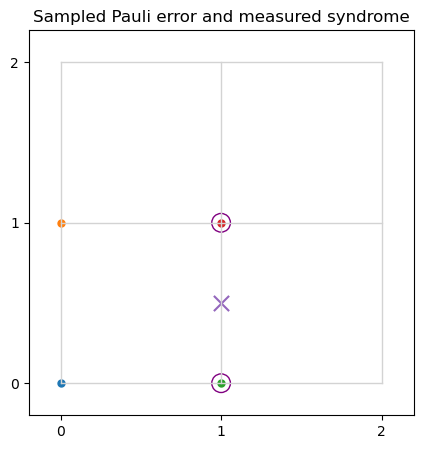

In [38]:
def edge_midpoint(code: ToricCode, q: int):
    L = code.L
    if q < L * L:
        y, x = divmod(q, L)
        return x + 0.5, y
    q2 = q - L * L
    y, x = divmod(q2, L)
    return x, y + 0.5

def draw_toric_state(code: ToricCode, x_err=None, z_err=None,
                     syn_star=None, syn_plaquette=None,
                     title="Toric code sample"):
    L = code.L
    fig, ax = plt.subplots(figsize=(5, 5))

    for x in range(L + 1):
        ax.plot([x, x], [0, L], color="lightgray", lw=1)
    for y in range(L + 1):
        ax.plot([0, L], [y, y], color="lightgray", lw=1)

    for x in range(L):
        for y in range(L):
            ax.scatter([x], [y], s=25)

    if x_err is not None:
        for q in np.where(x_err)[0]:
            xm, ym = edge_midpoint(code, q)
            ax.scatter([xm], [ym], s=120, marker="s")

    if z_err is not None:
        for q in np.where(z_err)[0]:
            xm, ym = edge_midpoint(code, q)
            ax.scatter([xm], [ym], s=120, marker="x")

    if syn_star is not None:
        for s in np.where(syn_star)[0]:
            y, x = divmod(s, L)
            ax.scatter([x], [y], s=180, marker="o", facecolors="none",edgecolors="purple")

    if syn_plaquette is not None:
        for p in np.where(syn_plaquette)[0]:
            y, x = divmod(p, L)
            ax.scatter([x + 0.5], [y + 0.5], s=180, marker="^", facecolors="none", edgecolors="orange")

    ax.set_xlim(-0.2, L + 0.2)
    ax.set_ylim(-0.2, L + 0.2)
    ax.set_aspect("equal")
    ax.set_xticks(range(L + 1))
    ax.set_yticks(range(L + 1))
    ax.set_title(title)
    plt.show()

draw_toric_state(
    code,
    x_err=x_err,
    z_err=z_err,
    syn_star=syn_star_expected,
    syn_plaquette=syn_plaq_expected,
    title="Sampled Pauli error and measured syndrome"
)


## 10. Estimate the logical failure rate (distance-2 Toric code)

Wrapped everything into one trial function. Then, run 100 shots for each error rate to estimate the logical failure rate.

In [40]:
def run_one_qiskit_trial(code: ToricCode, psi00: np.ndarray,
                         Hx: np.ndarray, Hz: np.ndarray,
                         LX: np.ndarray, LZ: np.ndarray,
                         matching_X: Matching, matching_Z: Matching,
                         p: float, simulator, seed=None):
    rng = np.random.default_rng(seed)
    x_err, z_err = sample_pauli_error(code.n, p, rng=rng)

    qc = build_syndrome_circuit(code, psi00, x_err, z_err)
    tqc = transpile(qc, simulator)
    result = simulator.run(tqc, shots=1).result()
    counts = result.get_counts()
    syn_plaq, syn_star = counts_to_syndrome_arrays(counts, code.n_plaquette, code.n_star)

    x_corr = matching_X.decode(syn_plaq).astype(np.uint8)
    z_corr = matching_Z.decode(syn_star).astype(np.uint8)

    x_residual = x_err ^ x_corr
    z_residual = z_err ^ z_corr

    fail_x = bool(np.any((LZ @ x_residual) % 2))
    fail_z = bool(np.any((LX @ z_residual) % 2))

    return {
        "x_err": x_err,
        "z_err": z_err,
        "syn_plaq": syn_plaq,
        "syn_star": syn_star,
        "fail": bool(fail_x or fail_z),
    }

def estimate_logical_failure_qiskit(code: ToricCode, psi00: np.ndarray,
                                    Hx: np.ndarray, Hz: np.ndarray,
                                    LX: np.ndarray, LZ: np.ndarray,
                                    matching_X: Matching, matching_Z: Matching,
                                    p: float, shots: int = 30):
    sim = AerSimulator()
    fails = 0
    for t in range(shots):
        out = run_one_qiskit_trial(
            code, psi00, Hx, Hz, LX, LZ,
            matching_X, matching_Z,
            p=p, simulator=sim, seed=1000 + t
        )
        fails += int(out["fail"])
    return fails / shots

p_list = [0.02, 0.05, 0.08, 0.12]
fail_rates_qiskit = [
    estimate_logical_failure_qiskit(
        code, psi00, Hx, Hz, LX, LZ,
        matching_X, matching_Z,
        p=p, shots=100
    )
    for p in p_list
]

for p, f in zip(p_list, fail_rates_qiskit):
    print(f"p = {p:.3f}, logical failure ≈ {f:.3f}")


p = 0.020, logical failure ≈ 0.030
p = 0.050, logical failure ≈ 0.110
p = 0.080, logical failure ≈ 0.180
p = 0.120, logical failure ≈ 0.300


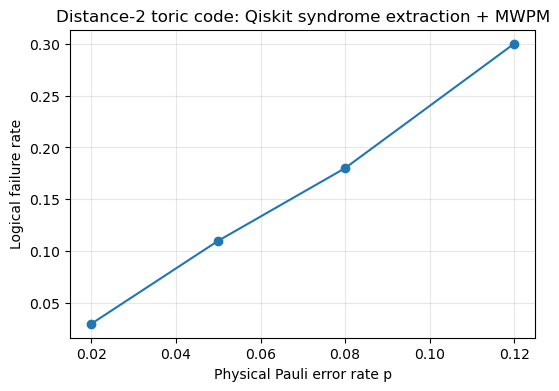

In [41]:
plt.figure(figsize=(6, 4))
plt.plot(p_list, fail_rates_qiskit, marker="o")
plt.xlabel("Physical Pauli error rate p")
plt.ylabel("Logical failure rate")
plt.title("Distance-2 toric code: Qiskit syndrome extraction + MWPM")
plt.grid(True, alpha=0.3)
plt.show()
